# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 17:17:31,976] A new study created in memory with name: no-name-66383589-6429-4dc7-8a90-8963eb59f8c2
[I 2026-04-09 17:17:32,168] Trial 0 finished with value: 0.7244094488188977 and parameters: {'n_estimators': 211, 'max_depth': 10}. Best is trial 0 with value: 0.7244094488188977.
[I 2026-04-09 17:17:32,309] Trial 1 finished with value: 0.7058823529411765 and parameters: {'n_estimators': 179, 'max_depth': 5}. Best is trial 0 with value: 0.7244094488188977.
[I 2026-04-09 17:17:32,451] Trial 2 finished with value: 0.7286821705426356 and parameters: {'n_estimators': 155, 'max_depth': 10}. Best is trial 2 with value: 0.7286821705426356.
[I 2026-04-09 17:17:32,553] Trial 3 finished with value: 0.7538461538461538 and parameters: {'n_estimators': 109, 'max_depth': 13}. Best is trial 3 with value: 0.7538461538461538.
[I 2026-04-09 17:17:32,699] Trial 4 finished with value: 0.7286821705426356 and parameters: {'n_estimators': 160, 'max_depth': 10}. Best is trial 3 with value: 0.75384

RF F1: 0.7480916030534351
LR F1: 0.71875
SVM F1: 0.71875
KNN F1: 0.7536231884057971


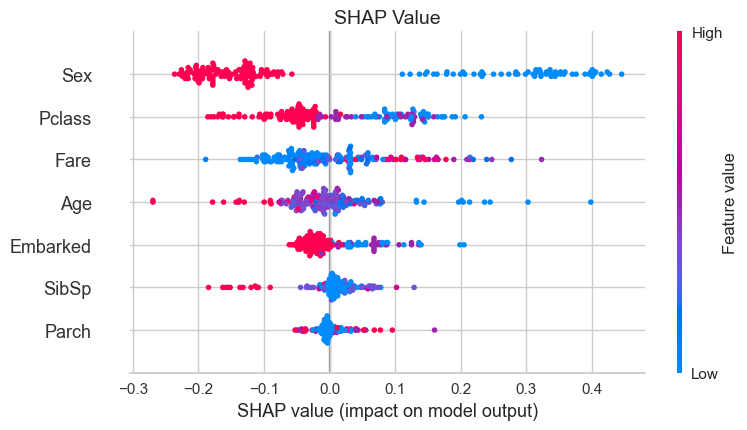

Stacking F1: 0.734375


In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다. -> 이 코드 아래 개별적으로 따로 진행

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기




# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

In [9]:
df = pd.read_csv('titanic.csv')

print(df['Sex'].unique())  # 원래 값 확인

df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

print(df['Sex'].unique())  # 변환 후 확인
print("female = 0, male = 1")


['male' 'female']
[1 0]
female = 0, male = 1


In [10]:
#EDA 제안
df.info()

#모든 데이터의 결측치는 0이므로 초반 코드에서 age와 emarked, 외의 데이터들도 적절하게 결측치 처리가 되었음을 확인할 수 있다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [11]:
print(df.isnull().sum())

print(df['Survived'].value_counts())
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())
print(df[['Age', 'Fare']].describe())



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64
Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


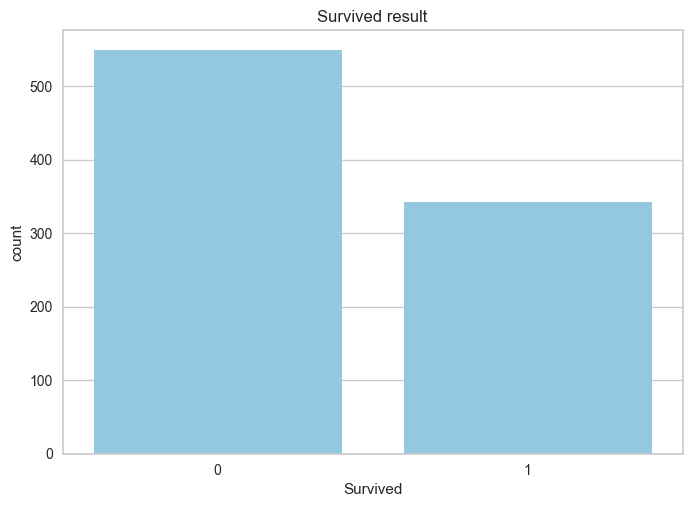

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=df, color="skyblue")
plt.title("Survived result")
plt.show()
#생존 분포를 보니 0(사망)은 549명, 1(생존)은 342명으로 비생존자가 더 많음을 확인할 수 있다.

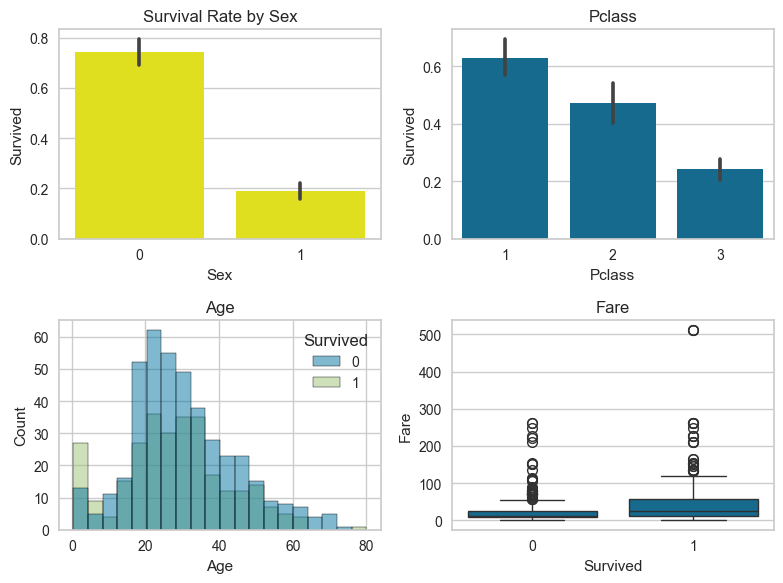

In [13]:
plt.figure(figsize=(8, 6))

plt.subplot(2,2,1)
sns.barplot(x='Sex', y='Survived', data=df, color="yellow")
plt.title("Survival Rate by Sex")


plt.subplot(2,2,2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Pclass")


plt.subplot(2,2,3)
sns.histplot(x="Age", hue="Survived", data=df)
plt.title("Age")

plt.subplot(2,2,4)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare")


plt.tight_layout()
plt.show()

#그래프로 도출해본 결과 각각의 변수들은 서로 다른 영향을 보인다
#sex별 생존률을 보면 0은 0.741, 1은 0.189로 많이 차이가 난다 -> 성별이 생존률에 큰 영향을 주는 변수라고 해석할 수 있다
#또한 생존률이 1등석 > 2등석 > 3등석 순으로 감소하는 것을 확인할 수 있는데, 좋은 Pclass를 가질 수록 생존 비율이 높은 것을알 수 있다.
#나이 분포를 보면 어린 승객일수록 생존 비율이 높게 나타난다 -> 구조할 때 어린이가 먼저 구조 되었을 가능성이 있다.
#마지막으로 Fare을 보면 생존자의 경우 더 높은 운임 구간에 분포하는 것을 학인할 수 있다. 

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

상위 모델 3-4개 , 안 배운 모델은 사용금지

In [14]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')
#customer_id는 단순 식별자이므로 churn 예측과 직접적인 관계가 없다고 판단

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

corr = df.corr()


#범주형 변수인 country와 gender은 모델이 숫자로 인식할 수 있도록 인코딩 

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df["churn"])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0550
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.3820
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1420
rf,Random Forest Classifier,0.8580,0.8440,0.4401,0.7621,0.5571,0.4800,0.5060,0.1360
et,Extra Trees Classifier,0.8550,0.8419,0.4322,0.7525,0.5478,0.4691,0.4952,0.0880
dt,Decision Tree Classifier,0.7848,0.6768,0.4943,0.4733,0.4832,0.3475,0.3479,0.0100
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0060
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0070
lr,Logistic Regression,0.8123,0.7424,0.1937,0.6316,0.2949,0.2207,0.2729,0.8690
ridge,Ridge Classifier,0.8038,0.7611,0.0964,0.6202,0.1664,0.1181,0.1863,0.0070


In [15]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

print(df.info())
print(df.isnull().sum())
print(df["churn"].value_counts())

#현재 데이터에서 결측치는 모두 0으로 결측치 처리가 잘 되어 있다고 보면 된다.
#타겟 변수의 churn은 0이 7,963이고 1이 2,037으로 불균형하다.
#이탈 고객보단 비이탈 고객이 더 많이 존재한다.
#accuracy는 전체 맞춘 비율만 보기 때문에 소수 클래스를 무시 가능하다 그래서 F1 score를 봐야한다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_nu

In [16]:
print(df.groupby('gender')['churn'].mean())
print(df.groupby('country')['churn'].mean())

#gender 별 churn 비율을 확인하였을 때, 여성 고객 이탈률은 약 0.25, 남성 고객 이탈률은 약 0.16으로 나타나며 성별에 따라 이탈률 차이가 존재함을 확인하였다.
#또한 country별 churn 비율을 보면 독일이 프랑스와 스페인 대비 야가 2배 수준가량 높은 것으로 확인된다. 
#이를 통해 특정 국가에서 고객 이탈이 집중되어 있음을 의미하며, 각각의 country 차별화된 서비스 전략이 필요할 수도 있다는 가능성을 보여준다.


gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64
country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64


In [17]:
print(df.groupby('churn')[['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']].mean())

#이탈 여부에 따라 각각의 변수 평군을 비교하였다
#신용 점수에서 이탈고객(1)의 평균 신용 점수는 645점이며 비이탈고객(0)은 651점으로 신용점수가 낮을수록 이탈할 가능성이 조금 높을 수 있다.
#age를 보면 비이탈고객의 평균나이와 이탈고객의 평균 나이는 약 7살 정도 차이나며 상대적으로 나이가 많은 고객이 이탈할 경향이 높다
#tenure은 크게 차이가 없다는 것이 확인되며 이 변수는 이탈에 큰 영향을 준다고 판단하기 어렵다

       credit_score        age    tenure       balance  estimated_salary
churn                                                                   
0        651.853196  37.408389  5.033279  72745.296779      99738.391772
1        645.351497  44.837997  4.932744  91108.539337     101465.677531


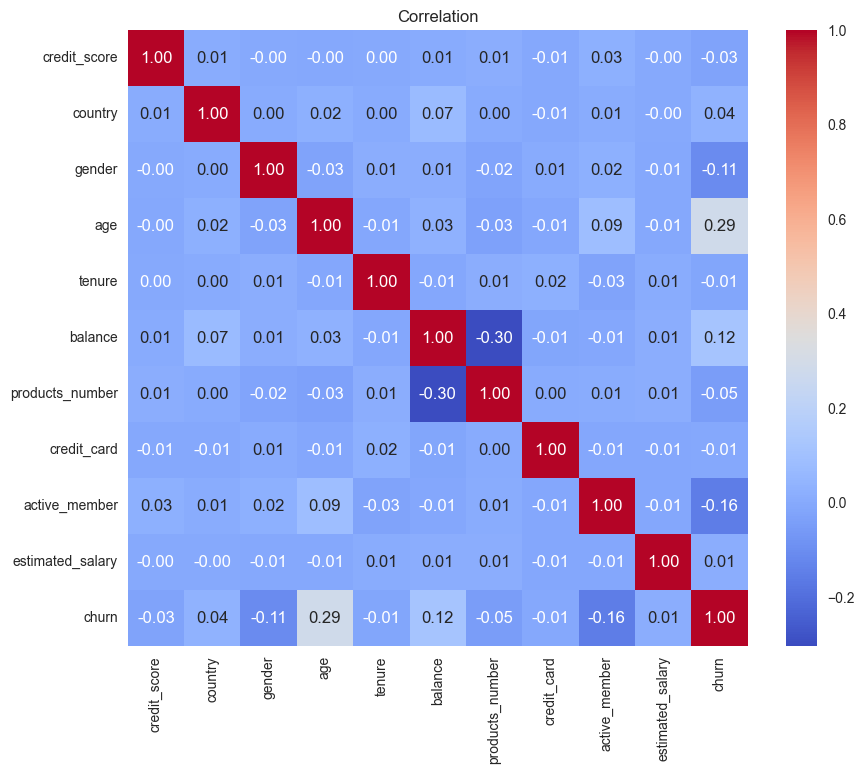

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation")
plt.show()


#age와 churn의 상관계수는 0.29로 변수들 중에서 가장 큰 양의 관계를 보인다. -> 즉 나이가 많을수록 이탈 가능성이 상대적으로 높아질 수 있다.
#active_memeber 와 churn의 상관계수는 -0.16으로 음의 관계를 보인다. 즉, 활덩성이 있는 고객일수록 이탈 가능성이 낮아질 가능성이 있다.
#balance와 products_number은 -0.3으로 뚜렷한 음의 관계를 보인다. 즉, 상품 수가 많을수록 잔고가 낮게 나타나는 경향이 있을 수도 있다.
#반면 credit_score, tenure, estimated_salary는 churn과의 선형 관계가 크지 않아 단독 변수보다는 다른 변수와 함께 해석할 필요가 있다고 보았다.


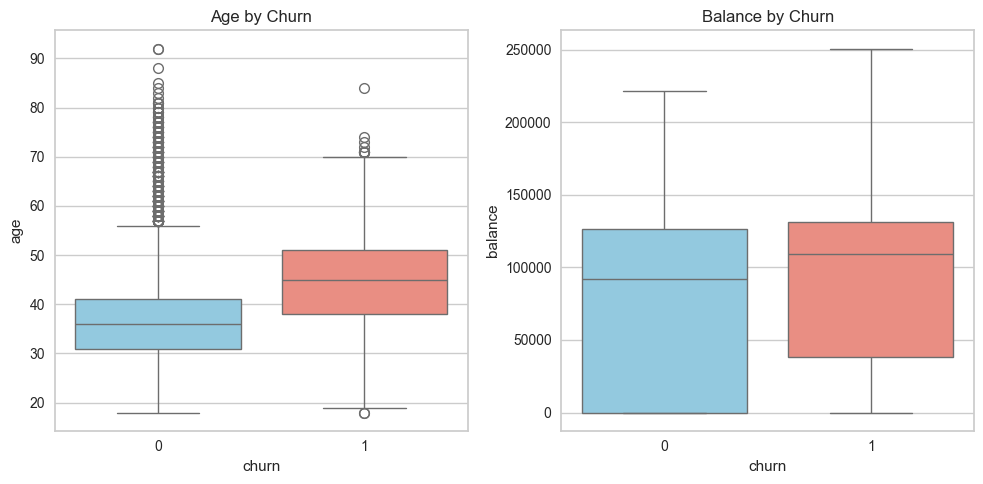

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='age', data=df, palette=['skyblue', 'salmon'])
plt.title("Age by Churn")

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='balance', data=df, palette=['skyblue', 'salmon'])
plt.title("Balance by Churn")

plt.tight_layout()
plt.show()

#이탈 고객은 비이탈고객보다 나이가 많고 잔고도 더 높은 것을 보인다.
#따라서 age와 balance는 고객 이탈을 설명하는 핵심 후보 변수로 볼 수 있을 것이다.


In [ ]:
#customer_id는 단순 식별자라서 예측과 직접 관련이 없다고 판단하여 제거하였음
#country와 gender는 범주형 변수이므로 labelEncoder로 수치형 변환을 해줌
#결측치는 존재하지 않음

#churn 비율은 약 20%로 비이탈 고객이 더 많은 불균형 데이터이다
#gender와 country에 따라 churn 비율이 차이가 나타났고, 특히 독일 고객의 이탈률이 상대적으로 높았다.
#또한 churn 고객은 평균 age와 balance가 더 높았으며, 상관관계에서도 age는 양의 관계, active_member는 음의 관계를 보여 age, balance, active_member를 주요 설명 변수 후보로 판단할 수 있을 것 같다.

In [21]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)

# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기


#pycaret을 통해 모델들을 비교한 결과, F1-score 기준 상위 4개 모델을 보면 (AdaBoost, LightGBM, GradientBoosting, RandomForest)가 선정되었다.
#선정된 상위 4개의 모델에 대해 oputuna를 활용해 하이퍼파라미터를 최적화한다.
#성능평가는 클래스의 불균형을 고려해서 Accuracy 대신 F1-score을 기준으로 수행한다.


#데이터를 분리하기 위해 train_test_split을 import 
from sklearn.model_selection import train_test_split
#f1-score로 성능평가
from sklearn.metrics import f1_score
#상위 4개 모델 import
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
#최적화 
import optuna

# X데이터에는 결과값인 churn을 제외함
X = df.drop('churn', axis=1)
#y데이터에는 결과값 churn을 넣는다
y = df['churn']

# train / valid split
#8:2 비율로 분리
#클래스 비율을 유지하기 위해 statify 사용
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. AdaBoost 모델
def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),  #n-estimators : 모델을 반복적으로 학습하는 횟수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0) #learning_rate : 각 모델의 반영 강도
    }
    model = AdaBoostClassifier(**params, random_state=42)  #Optuna에서 탐색한 파라미터로 AdaBoost 모델 생성
    model.fit(X_train, y_train)  #학습 데이터로 모델 학습
    pred = model.predict(X_valid)  #예측 수행
    return f1_score(y_valid, pred)  #실제 값과 예측 값을 비교하여 F1-score 반환

# 2. LightGBM 모델
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),  #max_depth : 트리 깊이 제한
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),  #num_leaves : 트리의 복잡도 조절
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30) #최소 데이터 수 제한
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)  
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 3. GradientBoosting
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)  #일부 데이터만 사용하여 학습
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 4. RandomForest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
        #min_sample_split/leaf : 느드 분할 조건 
    }
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# Optuna 탐색
#각 모델별로 하이퍼파라미터를 자동으로 탐색하여 최적의 조합을 찾는다
study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)
#creat_study : 탐색 시작
#optimize : 여러 번 시도하면서 최적 찾기 

# 최적 파라미터로 모델 정의
#Optuna에서 찾은 최적의 하이퍼파라미터를 사용하여 모델 다시 생성
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

# 각 모델을 학습한 후 validation 데이터에 대해 예측 수항하고 f1-score 기준으로 성능 비교
for name, model in [('ADA', ada), ('LGBM', lgbm), ('GBC', gbc), ('RF', rf)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))




[I 2026-04-09 17:17:57,697] A new study created in memory with name: no-name-2c49937b-a910-4e8b-b36d-9581a541de08
[I 2026-04-09 17:17:59,400] Trial 0 finished with value: 0.5705794947994056 and parameters: {'n_estimators': 295, 'learning_rate': 0.7858857292914265}. Best is trial 0 with value: 0.5705794947994056.
[I 2026-04-09 17:18:00,751] Trial 1 finished with value: 0.5769230769230769 and parameters: {'n_estimators': 230, 'learning_rate': 0.7510892417973685}. Best is trial 1 with value: 0.5769230769230769.
[I 2026-04-09 17:18:02,105] Trial 2 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 233, 'learning_rate': 0.8179581844165738}. Best is trial 1 with value: 0.5769230769230769.
[I 2026-04-09 17:18:03,275] Trial 3 finished with value: 0.5740181268882175 and parameters: {'n_estimators': 193, 'learning_rate': 0.23323753138565936}. Best is trial 1 with value: 0.5769230769230769.
[I 2026-04-09 17:18:04,647] Trial 4 finished with value: 0.5523809523809524 and param

ADA F1: 0.5774436090225564
LGBM F1: 0.5907046476761619
GBC F1: 0.6029850746268657
RF F1: 0.56957928802589


#### 최종
pycaret 비교 결과 F1-score 기준 상위 4개 모델인 AdaBoost, LightGBM, GradientBoosting, RnadomForest를 최종 후보로 선정되었다.

부스팅 계열 모델은 churn 고객을 세밀하게 구분할 수 있고, LightGBM은 비선형 관계 학습에 강점이 있으며, RandomForest는 안정적인 성능과 변수 중요도 해석이 가능하다는 점에서 채택하였고,

optuna 하이퍼파라미터 튜닝으로 각 모델의 성능을 재검증해 최종 모델을 비교

-> Optuna로 각 모델의 하이퍼파라미터를 최적화하고 validation F1-score를 비교한 결과,

GradientBoosting이 약 0.603으로 가장 우수하였으며, 따라서 최종 모델은 GradientBoostingClassifier로 선정.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 데이터 다시 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 불필요 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# X, y 분리
X = df.drop('churn', axis=1)
y = df['churn']

# 학습/검증 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



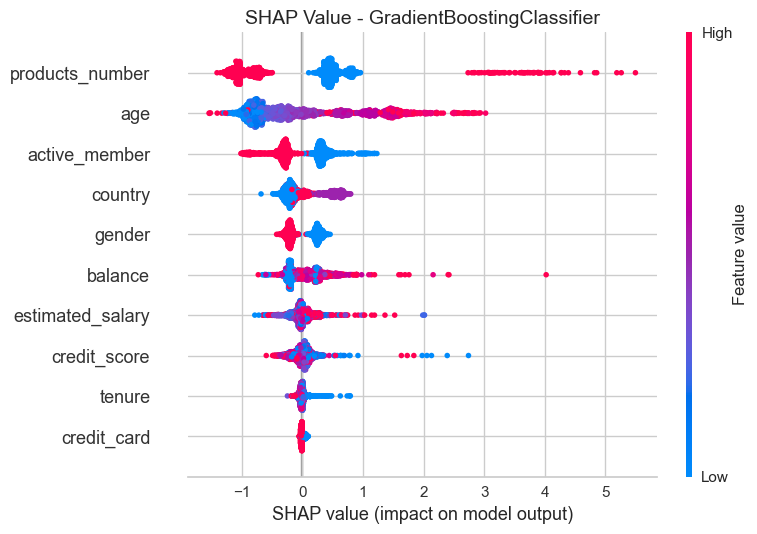

Stacking F1: 0.6024096385542169
Stacking Accuracy: 0.868


In [25]:
#모델 4개 중 1개를 선택하여 SHAP Value 시각화

import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    GradientBoostingClassifier,
    StackingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier

# Optuna 튜닝 결과 중 가장 성능이 좋았던 GradientBoosting 모델을 다시 생성
# SHAP은 모델이 어떤 변수를 중요하게 사용하는지 해석하기 위한 기법이므로,
# 성능이 높은 모델을 기준으로 분석하는 것이 논리적이라고 판단하였다.
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
gbc.fit(X_train, y_train)

# SHAP 시각화에서는 변수명을 함께 보여주는 것이 해석에 유리하므로 DataFrame으로 변환
X_valid_df = pd.DataFrame(X_valid, columns=X.columns)

# SHAP 값 계산
explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X_valid_df)

# 이진 분류 문제에서는 SHAP 출력 형태가 모델에 따라 다를 수 있으므로 형태를 보정
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# SHAP 요약 시각화
shap.summary_plot(
    shap_values,
    X_valid_df,
    feature_names=X.columns,
    plot_type="dot",
    show=False
)
plt.title("SHAP Value - GradientBoostingClassifier", fontsize=14)
plt.tight_layout()
plt.show()

# 상위 4개 모델을 Stacking 하여 최종 성능 비교


# Optuna에서 찾은 최적 파라미터를 사용하여 상위 4개 모델 다시 정의
ada = AdaBoostClassifier(**study_ada.best_params, random_state=42)
lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1)
gbc = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
rf = RandomForestClassifier(**study_rf.best_params, random_state=42)

# 전방 모델(base models) 설정
# 각 모델이 서로 다른 방식으로 예측하도록 하여,
# 단일 모델보다 더 안정적인 성능을 얻고자 하였다.
estimators = [
    ('ada', ada),
    ('lgbm', lgbm),
    ('gbc', gbc),
    ('rf', rf)
]

# 후방 모델(meta model) 설정
# 전방 모델들의 예측 결과를 입력받아 최종 예측을 수행
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

# Stacking 학습 및 예측
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_valid)

# 최종 성능 출력
# Accuracy는 전체 정답 비율, F1-score는 불균형 데이터에서 precision/recall을 함께 고려한 지표이다.
print("Stacking F1:", f1_score(y_valid, stack_pred))
print("Stacking Accuracy:", accuracy_score(y_valid, stack_pred))

In [ ]:
# 4. SHAP value 사후분석
# SHAP 분석 결과 GradientBoostingClassifier는 products_number, age, active_member, country 순으로 churn 예측에 큰 영향을 주는 것으로 나타났다.
# 특히 products_number 값이 큰 고객은 SHAP 값이 크게 증가하는 구간이 보여, 특정 상품 보유 패턴이 이탈 가능성을 높일 수 있다고 해석했다.
# 또한 age가 높을수록 churn 방향으로 기여하는 경향이 나타나, 고연령 고객이 상대적으로 이탈 위험이 높을 가능성을 확인했다.
# 반면 active_member는 값이 높을수록 churn을 낮추는 방향으로 작용해, 실제 서비스 이용 활성도가 이탈 방지에 중요하다고 판단했다.
# 따라서 은행은 상품 수가 많거나 고연령이면서 비활성 상태인 고객을 우선 관리 대상으로 설정할 필요가 있다.


In [ ]:
# 5. validation score 적절하게 출력
# Optuna 튜닝 후 validation 데이터에서 모델 성능을 비교한 결과, GradientBoostingClassifier의 F1-score가 약 0.603으로 가장 높게 나타났다.
# 또한 상위 4개 모델을 stacking한 결과 F1-score는 약 0.602, Accuracy는 0.868로 확인되었다.
# 본 데이터는 churn 비율이 불균형하므로 accuracy보다 F1-score를 중심으로 해석하였다.
# GradientBoosting 단일 모델이 충분히 효과적인 모델로 판단된다.


1, 주석에 GPT 흔적
2, 결과에 맞지 않는 해석
3. 결과에 맞지 않는 인사이트 제안